<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

In [15]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Shape of X: (150, 4)
Shape of y: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [16]:
knn = KNeighborsClassifier(n_neighbors=5)

scores = cross_val_score(knn, X, y, cv=10)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [1.         0.93333333 1.         1.         0.86666667 0.93333333
 0.93333333 1.         1.         1.        ]
Mean accuracy: 0.9666666666666668


In [17]:
k_range = range(1, 31)
mean_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    mean_scores.append(scores.mean())

In [18]:
for k, score in zip(k_range, mean_scores):
    print(f"k = {k}, Accuracy = {score:.4f}")

k = 1, Accuracy = 0.9600
k = 2, Accuracy = 0.9533
k = 3, Accuracy = 0.9667
k = 4, Accuracy = 0.9667
k = 5, Accuracy = 0.9667
k = 6, Accuracy = 0.9667
k = 7, Accuracy = 0.9667
k = 8, Accuracy = 0.9667
k = 9, Accuracy = 0.9733
k = 10, Accuracy = 0.9667
k = 11, Accuracy = 0.9667
k = 12, Accuracy = 0.9733
k = 13, Accuracy = 0.9800
k = 14, Accuracy = 0.9733
k = 15, Accuracy = 0.9733
k = 16, Accuracy = 0.9733
k = 17, Accuracy = 0.9733
k = 18, Accuracy = 0.9800
k = 19, Accuracy = 0.9733
k = 20, Accuracy = 0.9800
k = 21, Accuracy = 0.9667
k = 22, Accuracy = 0.9667
k = 23, Accuracy = 0.9733
k = 24, Accuracy = 0.9600
k = 25, Accuracy = 0.9667
k = 26, Accuracy = 0.9600
k = 27, Accuracy = 0.9667
k = 28, Accuracy = 0.9533
k = 29, Accuracy = 0.9533
k = 30, Accuracy = 0.9533


In [19]:
best_score = max(mean_scores)
best_k = list(k_range)[mean_scores.index(best_score)]

print("Optimal k:", best_k)
print("Best cross-validated accuracy:", best_score)

Optimal k: 13
Best cross-validated accuracy: 0.9800000000000001


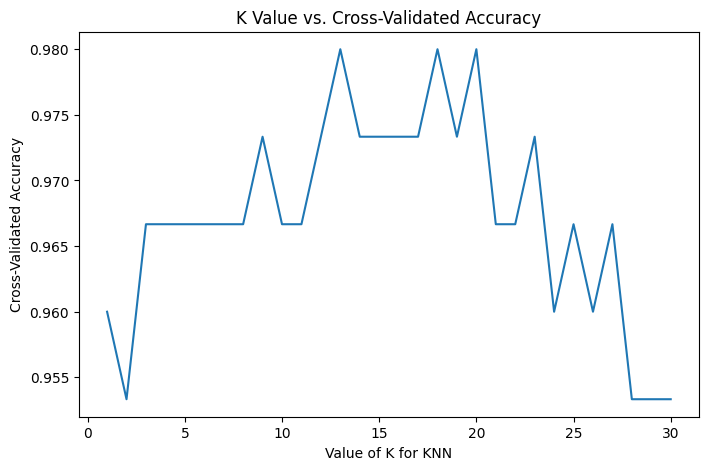

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(k_range, mean_scores)

plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("K Value vs. Cross-Validated Accuracy")

plt.show()

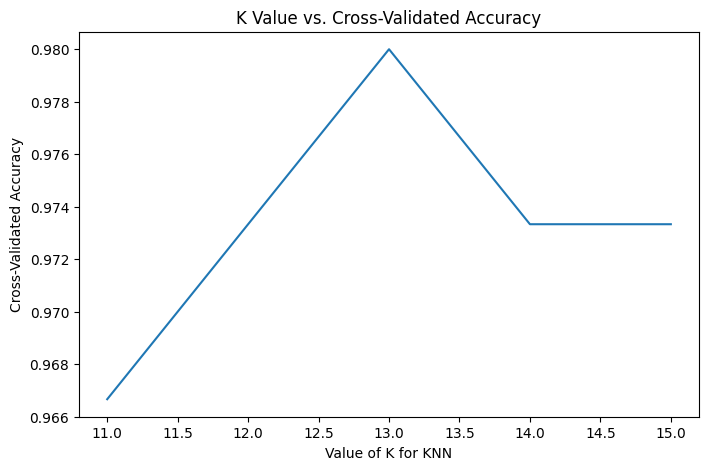

In [21]:
selected_k = range(11, 16)
selected_scores = []

for k in selected_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    selected_scores.append(scores.mean())

plt.figure(figsize=(8, 5))

plt.plot(selected_k, selected_scores)

plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("K Value vs. Cross-Validated Accuracy")

plt.show()

In [22]:
param_grid = {
    "n_neighbors": range(1, 31)
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=10,
    scoring="accuracy"
)

In [23]:
grid.fit(X, y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)}, scoring='accuracy')

In [24]:
print("Best parameter:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

Best parameter: {'n_neighbors': 13}
Best cross-validation accuracy: 0.9800000000000001


In [25]:
#The results show that k=13 is the best choice for the KNN model. GridSearchCV also confirms this result with the highest cross-validation accuracy.